# Librerias

In [55]:
import importlib
import subprocess
import sys

# Mapeo de imports → nombres reales de paquetes en pip
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",   
    "plotly": "plotly",
    "stargazer": "stargazer",
    "StepMix":"StepMix",
}

def safe_pip_install(package):
    """Instala un paquete si no está, sin actualizar."""
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print(f"✓ {package} instalado correctamente.")
    except Exception:
        print(f"⚠ No se pudo instalar {package}. Puede estar bloqueado por Anaconda.")

def install_if_missing(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        print(f"✔ {import_name} ya está instalado.")
    except ImportError:
        print(f"✖ {import_name} no está instalado. Instalando {pip_name}...")
        safe_pip_install(pip_name)

print("📦 Verificando librerías necesarias...\n")

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

print("\n🎉 Todas las librerías están listas.")


📦 Verificando librerías necesarias...

✔ numpy ya está instalado.
✔ pandas ya está instalado.
✔ matplotlib ya está instalado.
✔ scipy ya está instalado.
✔ seaborn ya está instalado.
✔ statsmodels ya está instalado.
✔ sklearn ya está instalado.
✔ plotly ya está instalado.
✔ stargazer ya está instalado.
✖ StepMix no está instalado. Instalando StepMix...
✓ StepMix instalado correctamente.

🎉 Todas las librerías están listas.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stepmix.stepmix import StepMix
#from IPython.display import Image
from stepmix.utils import get_mixed_descriptor

from sklearn import preprocessing
from sklearn.cluster import KMeans
#from statsmodels.tsa.arima.model import ARIMA

from deep_translator import GoogleTranslator

import warnings
warnings.filterwarnings("ignore")

# Limpieza y tratamiento de datos

## Lectura de datos

In [57]:
df_consumidores=pd.read_csv("customers.csv")
df_compras=pd.read_csv("orders.csv")

#contar nulos por columna
display(df_consumidores.isnull().sum())
display(df_compras.isnull().sum())


customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

order_id                            0
customer_id                         0
order_date                          0
year                                0
month                               0
quarter                             0
day_of_week                         0
product_name                        0
category                            0
unit_price_usd                      0
quantity                            0
subtotal_usd                        0
discount_pct                        0
discount_amount_usd                 0
shipping_fee_usd                    0
tax_pct                             0
tax_amount_usd                      0
total_amount_usd                    0
payment_method                      0
device_used                         0
delivery_days                       0
delivery_date                       0
order_status                        0
returned                            0
customer_rating                 15749
session_duration_minutes            0
pages_viewed

En general se observa que no existen valores nulos en el data de consumidores pero si existen 15796 valores nulos en el df de compras,en particular todos los nulos se encuentra en la columna customer_raiting

## Union de bases de datos

Se aprecia ademas que ambos df tiene la columna customer id,con la que se pueden unir usando una relacion 1:varios,esto ya que la columna is_repeat_customer del de compras nos señala que un cosumidor puede aparecer mas de una vez en ella

In [58]:
df = pd.merge(
    df_consumidores,
    df_compras,
    on='customer_id',
    how='inner',
    validate='one_to_many'
)

## Traduccion columnas

para mayor facilidad a la hora de intepretar las variables en los df,se traduciran las columnas al español

In [59]:
# Diccionario de traducción al español
traduccion_columnas = {
    'customer_id': 'id_cliente',
    'country': 'pais',
    'age': 'edad',
    'gender': 'genero',
    'membership_tier': 'nivel_membresia',
    'registration_date': 'fecha_registro',
    'total_orders': 'total_pedidos',
    'total_spend_usd': 'gasto_total_usd',
    'avg_order_value_usd': 'valor_promedio_pedido_usd',
    'days_since_last_purchase': 'dias_desde_ultima_compra',
    'preferred_category': 'categoria_preferida',
    'preferred_device': 'dispositivo_preferido',
    'preferred_payment_method': 'metodo_pago_preferido',
    'acquisition_channel': 'canal_adquisicion',
    'reviews_given': 'resenas_realizadas',
    'avg_review_score': 'puntaje_promedio_resenas',
    'returns_made': 'devoluciones_realizadas',
    'wishlist_items': 'items_lista_deseos',
    'newsletter_subscribed': 'suscrito_newsletter',
    'churned': 'abandono_cliente',

    'order_id': 'id_pedido',
    'order_date': 'fecha_pedido',
    'year': 'anio',
    'month': 'mes',
    'quarter': 'trimestre',
    'day_of_week': 'dia_semana',

    'product_name': 'nombre_producto',
    'category': 'categoria',

    'unit_price_usd': 'precio_unitario_usd',
    'quantity': 'cantidad',
    'subtotal_usd': 'subtotal_usd',

    'discount_pct': 'porcentaje_descuento',
    'discount_amount_usd': 'monto_descuento_usd',

    'shipping_fee_usd': 'costo_envio_usd',

    'tax_pct': 'porcentaje_impuesto',
    'tax_amount_usd': 'monto_impuesto_usd',

    'total_amount_usd': 'monto_total_usd',

    'payment_method': 'metodo_pago',
    'device_used': 'dispositivo_usado',

    'delivery_days': 'dias_entrega',
    'delivery_date': 'fecha_entrega',

    'order_status': 'estado_pedido',
    'returned': 'devuelto',

    'customer_rating': 'calificacion_cliente',

    'session_duration_minutes': 'duracion_sesion_minutos',
    'pages_viewed_before_purchase': 'paginas_vistas_antes_compra',

    'is_repeat_customer': 'cliente_recurrente'
}

df.rename(columns=traduccion_columnas, inplace=True)
df_consumidores.rename(columns=traduccion_columnas, inplace=True)
df_compras.rename(columns=traduccion_columnas, inplace=True)

In [60]:
display(df_consumidores.head(5))

,id_cliente,pais,edad,genero,nivel_membresia,fecha_registro,total_pedidos,gasto_total_usd,valor_promedio_pedido_usd,dias_desde_ultima_compra,categoria_preferida,dispositivo_preferido,metodo_pago_preferido,canal_adquisicion,resenas_realizadas,puntaje_promedio_resenas,devoluciones_realizadas,items_lista_deseos,suscrito_newsletter,abandono_cliente
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


# Seleccion variables sociodemograficas y RFM

a continuacion se utiliza label encoding en distintas variables categoricas de df con el objetivo de probar como se comportan en los modelos de stepmix

In [61]:
continentes = {

    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',

    'Brazil': 'South America',

    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Netherlands': 'Europe',
    'Germany': 'Europe',
    'Poland': 'Europe',
    'Spain': 'Europe',
    'Italy': 'Europe',
    'Sweden': 'Europe',

    'Japan': 'Asia',
    'India': 'Asia',
    'South Korea': 'Asia',
    'Singapore': 'Asia',

    'UAE': 'Middle East',
    'Turkey': 'Middle East',

    'South Africa': 'Africa',

    'Australia': 'Oceania'
}

# Crear variable continente
df_consumidores["continente"] = df_consumidores["pais"].map(continentes)

# Encoding manual de continentes
encoding_continente = {
    'North America': 0,
    'South America': 1,
    'Europe': 2,
    'Asia': 3,
    'Middle East': 4,
    'Africa': 5,
    'Oceania': 6
}

df_consumidores["continente_enc"] = df_consumidores["continente"].map(encoding_continente)


# Encoding manual
encoding_membresia = {
    'Free': 0,
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
}

df_consumidores["nivel_membresia_enc"] = df_consumidores["nivel_membresia"].map(encoding_membresia)

# Encoding manual
encoding_membresia = {
    'Free': 0,
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
}

canal_encoding = {
    'Direct':          0,  # usuario llega solo, costo ~0
    'Organic Search':  1,  # SEO, sin pago directo
    'Referral':        2,  # recomendación, costo indirecto
    'Email Campaign':  3,  # requiere infraestructura
    'Social Media':    4,  # requiere gestión/contenido
    'Paid Ad':         5,  # costo directo por clic
}

df_consumidores['canal_adquisicion_enc'] = df_consumidores['canal_adquisicion'].map(canal_encoding)

categoria_encoding = {
    'Books':                  0,
    'Food & Grocery':         1,
    'Office Supplies':        2,
    'Pet Supplies':           3,
    'Toys & Games':           4,
    'Beauty & Personal Care': 5,
    'Health & Wellness':      6,
    'Clothing & Apparel':     7,
    'Sports & Outdoors':      8,
    'Home & Kitchen':         9,
    'Travel & Luggage':      10,
    'Automotive':            11,
    'Electronics':           12,
    'Jewelry & Accessories': 13,
}

df_consumidores['categoria_preferida_enc'] = df_consumidores['categoria_preferida'].map(categoria_encoding)




dispositivo_encoding = {
    'Mobile':  0,
    'Tablet':  1,
    'Desktop': 2,
}

df_consumidores['dispositivo_preferido_enc'] = df_consumidores['dispositivo_preferido'].map(dispositivo_encoding)

canal_encoding = {
    'Direct':          0,
    'Referral':        1,
    'Organic Search':  2,
    'Email Campaign':  3,
    'Social Media':    4,
    'Paid Ad':         5,
}

df_consumidores['canal_adquisicion_enc'] = df_consumidores['canal_adquisicion'].map(canal_encoding)




In [62]:
V_sociodemograficas=["continente_enc","nivel_membresia_enc",'edad','genero','valor_promedio_pedido_usd', 'gasto_total_usd','metodo_pago_preferido']
V_RFM=['dias_desde_ultima_compra',"Frequency","gasto_total_usd"]
df_consumidores['genero']=df_consumidores['genero'].replace(['Female','Male'], [0,1])
df_consumidores = df_consumidores[df_consumidores['genero'] != 'Other']

# modelo STP demografico

## modelo

In [ ]:
def evaluar_stepmix(df, binary=None, categorical=None, gaussian=None, k_min=2, k_max=9):
    # ✅ k_min=2 como mínimo (igual que la pauta)
    if k_min < 2:
        raise ValueError("k_min debe ser al menos 2 para calcular entropía relativa.")

    kwargs = {k: v for k, v in dict(binary=binary, categorical=categorical, gaussian=gaussian).items() if v}
    mixed_data, mixed_descriptor = get_mixed_descriptor(dataframe=df, **kwargs)

    K = range(k_min, k_max + 1)
    bics, entropias = [], []

    for k in K:
        m = StepMix(
            n_components=k,
            measurement=mixed_descriptor,
            verbose=0,
            random_state=2026,
            n_init=1         # ✅ múltiples inicializaciones, igual al n_init='auto' de KMeans
        ).fit(mixed_data)
        bics.append(m.sabic(mixed_data))
        entropias.append(m.relative_entropy(mixed_data))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, vals, titulo in zip(axes, [bics, entropias], ["SABIC ↓", "Entropía relativa ↑"]):
        ax.plot(list(K), vals, marker="o")
        ax.set_title(titulo)
        ax.set_xlabel("Número de clases (k)")  # ✅ etiqueta faltante
        ax.set_xticks(list(K))
    plt.tight_layout()
    plt.show()



#------------------------------------#



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def tarjetas_segmentos(df, col_pred, columnas, nombres_clase=None,
                       colores=None, figsize_w=5):
    """
    df          : dataframe con la columna de predicción
    col_pred    : nombre de la columna con el segmento (ej. 'mixed_pred')
    columnas    : lista de dicts con la config de cada métrica a mostrar
    nombres_clase: lista con nombres personalizados por clase (opcional)
    colores     : lista de colores hex (opcional)
    figsize_w   : ancho por tarjeta

    Ejemplo de columnas:
    columnas = [
        {"col": "gasto_total_usd",  "label": "Gasto promedio",   "tipo": "moneda"},
        {"col": "edad",             "label": "Edad promedio",     "tipo": "decimal"},
        {"col": "total_pedidos",    "label": "Pedidos promedio",  "tipo": "entero"},
        {"col": "genero",           "label": "Género dominante",  "tipo": "moda",
         "mapa": {0: "Mujer", 1: "Hombre"}},
        {"col": "nivel_membresia",  "label": "Membresía típica",  "tipo": "moda"},
    ]
    tipos disponibles:
        'moneda'  → $1,234
        'decimal' → 32.5
        'entero'  → 32
        'pct'     → 32.1%
        'moda'    → valor más frecuente (categórico)
    """

    COLS_DEFAULT = ["#2EC4B6","#E71D36","#FF9F1C","#8338EC","#3A86FF"]
    n_clases     = df[col_pred].nunique()
    n_total      = len(df)
    colores      = colores or COLS_DEFAULT
    nombres      = nombres_clase or [f"Clase {k}" for k in range(n_clases)]

    def formatear(valor, tipo, mapa=None):
        if tipo == "moda":
            return mapa.get(valor, str(valor)) if mapa else str(valor)
        if tipo == "moneda":  return f"${valor:,.0f}"
        if tipo == "decimal": return f"{valor:.1f}"
        if tipo == "entero":  return f"{int(valor):,}"
        if tipo == "pct":     return f"{valor:.1f}%"
        return str(valor)

    def calcular(sub, cfg):
        if cfg["tipo"] == "moda":
            val = sub[cfg["col"]].mode()[0]
        elif cfg["tipo"] == "segmento":                          # ← nuevo
            segmentado = pd.cut(sub[cfg["col"]], bins=cfg["bins"], labels=cfg["labels"])
            val = segmentado.mode()[0]
            return str(val)
        else:
            val = sub[cfg["col"]].mean()
        return formatear(val, cfg["tipo"], cfg.get("mapa"))

    # ── Calcular métricas ─────────────────────────────────────────────────────
    metricas = []
    for k in range(n_clases):
        sub = df[df[col_pred] == k]
        pct    = len(sub) / n_total * 100
        valores = [(cfg["label"], calcular(sub, cfg)) for cfg in columnas]
        metricas.append((pct, valores))

    # ── Figura ────────────────────────────────────────────────────────────────
    alto_base = 4 + len(columnas) * 0.6
    fig, axes = plt.subplots(1, n_clases, figsize=(figsize_w * n_clases, alto_base))
    fig.patch.set_facecolor("#F7F7F7")
    if n_clases == 1: axes = [axes]

    for i, ax in enumerate(axes):
        pct, valores = metricas[i]
        color = colores[i % len(colores)]

        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

        # Franja superior
        ax.add_patch(mpatches.FancyBboxPatch(
            (0, 0.82), 1, 0.18, boxstyle="square,pad=0",
            transform=ax.transAxes, color=color, clip_on=False, zorder=3))

        ax.text(0.5, 0.905, nombres[i], transform=ax.transAxes,
                ha="center", va="center", fontsize=13,
                fontweight="bold", color="white", zorder=4)

        # Porcentaje
        ax.text(0.5, 0.70, f"{pct:.1f}%", transform=ax.transAxes,
                ha="center", va="center", fontsize=26,
                fontweight="bold", color=color)
        ax.text(0.5, 0.60, "del total de clientes", transform=ax.transAxes,
                ha="center", va="center", fontsize=9, color="gray")

        ax.axhline(y=0.54, xmin=0.1, xmax=0.9, color="#EEEEEE", linewidth=1)

        # Métricas dinámicas
        n      = len(valores)
        ys     = [0.46 - i * (0.46 / n) for i in range(n)]

        for (label, valor), y in zip(valores, ys):
            ax.text(0.5, y,        label, transform=ax.transAxes,
                    ha="center", va="center", fontsize=9, color="gray")
            ax.text(0.5, y - 0.03, valor, transform=ax.transAxes,
                    ha="center", va="center", fontsize=12,
                    fontweight="bold", color="#222222")

    plt.tight_layout(pad=1.5)
    plt.savefig("tarjetas_segmentos.png", dpi=150, bbox_inches="tight")
    plt.show()





In [77]:
from sklearn.preprocessing import StandardScaler
from stepmix.utils import get_mixed_descriptor
from stepmix.stepmix import StepMix

# Variables gaussianas
vars_gaussianas = [
    "edad",
    "valor_promedio_pedido_usd",
    "gasto_total_usd",
    "puntaje_promedio_resenas"
]

# Crear copia del dataframe
df_stepmix = df_consumidores.copy()

# Escalar en la copia
scaler = StandardScaler()

df_stepmix[vars_gaussianas] = scaler.fit_transform(
    df_stepmix[vars_gaussianas]
)

mixed_data, mixed_descriptor = get_mixed_descriptor(
    dataframe=df_stepmix,

    binary=['genero'],

    categorical=[
        "continente_enc",
        "nivel_membresia_enc",
        "categoria_preferida_enc",
        'dispositivo_preferido_enc',
        "canal_adquisicion_enc"
    ],

    gaussian=vars_gaussianas,
)




Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.26s/it, max_LL=-1.07e+5, max_avg_LL=-13.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.11s/it, max_LL=-1.07e+5, max_avg_LL=-13.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.50s/it, max_LL=-1.07e+5, max_avg_LL=-13.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.14s/it, max_LL=-1.06e+5, max_avg_LL=-13.7]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:14<00:00, 14.22s/it, max_LL=-1.06e+5, max_avg_LL=-13.7]


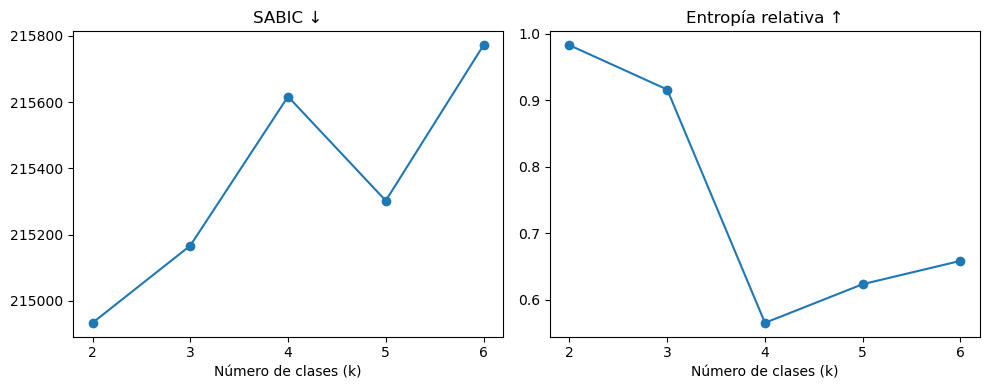

In [65]:
evaluar_stepmix(
    df_stepmix,
    binary=['genero'],
    categorical=["continente_enc","nivel_membresia_enc","categoria_preferida_enc",'dispositivo_preferido_enc',"canal_adquisicion_enc"],
    gaussian=vars_gaussianas,
    k_max=6
)

In [ ]:

# Modelo
model = StepMix(
    n_components=4,
    measurement=mixed_descriptor,
    verbose=1,
    random_state=2026,
    n_init=5
    
)

# Entrenar
model.fit(mixed_data)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.74s/it, max_LL=-1.07e+5, max_avg_LL=-13.8]

MODEL REPORT
    Measurement model parameters
          model_name      binary                        
          class_no             0       1       2       3
          param variable                                
          pis   genero    0.5372  0.6411  0.5145  0.3997


          model_name                        categorical                        
          class_no                                    0       1       2       3
          param variable                                                       
          pis   canal_adquisicion_enc_0          0.1057  0.0951  0.1043  0.1093
                canal_adquisicion_enc_1          0.0831  0.0630  0.0686  0.0541
                canal_adquisicion_enc_2          0.2803  0.2796  0.2863  0.2681
                canal_adquisicion_enc_3          0.1740  0.1372  0.1705  0.2240
                canal_adquisicion_enc_4          0.1868  0.2700  0.2087  0.1903
                canal_adquisicion_enc_5          0.1701  0.1551  0.1616  0.1542
    

,n_components,4
,n_steps,1
,measurement,"{'binary': {'model': 'binary', 'n_columns': 1}, 'categorical': {'model': 'categorical', 'n_columns': 5}, 'gaussian': {'model': 'gaussian', 'n_columns': 4}}"
,structural,'gaussian_unit'
,assignment,'modal'
,correction,None
,abs_tol,1e-10
,rel_tol,0.0
,max_iter,1000
,n_init,1
,save_param_init,False


## graficos

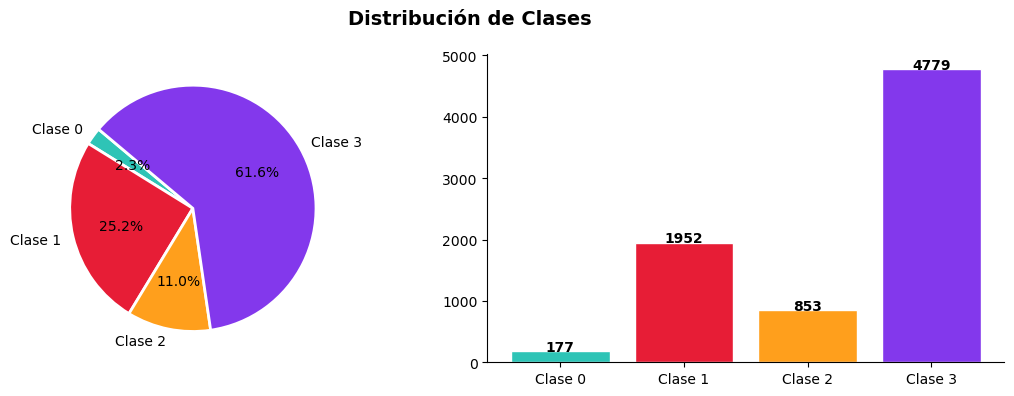

In [82]:
# ── Distribución de clases ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
df_consumidores['mixed_pred'] = model.predict(mixed_data)
conteo = df_consumidores['mixed_pred'].value_counts().sort_index()
clases = [f"Clase {i}" for i in conteo.index]
COLS = ["#2EC4B6","#E71D36","#FF9F1C","#8338EC","#3A86FF"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.pie(conteo, labels=clases, colors=COLS, autopct="%1.1f%%", startangle=140,
        wedgeprops=dict(linewidth=2, edgecolor="white"))
bars = ax2.bar(clases, conteo, color=COLS, edgecolor="white")
[ax2.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v),
          ha="center", fontweight="bold") for b, v in zip(bars, conteo)]
ax2.spines[["top","right"]].set_visible(False)
fig.suptitle("Distribución de Clases", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

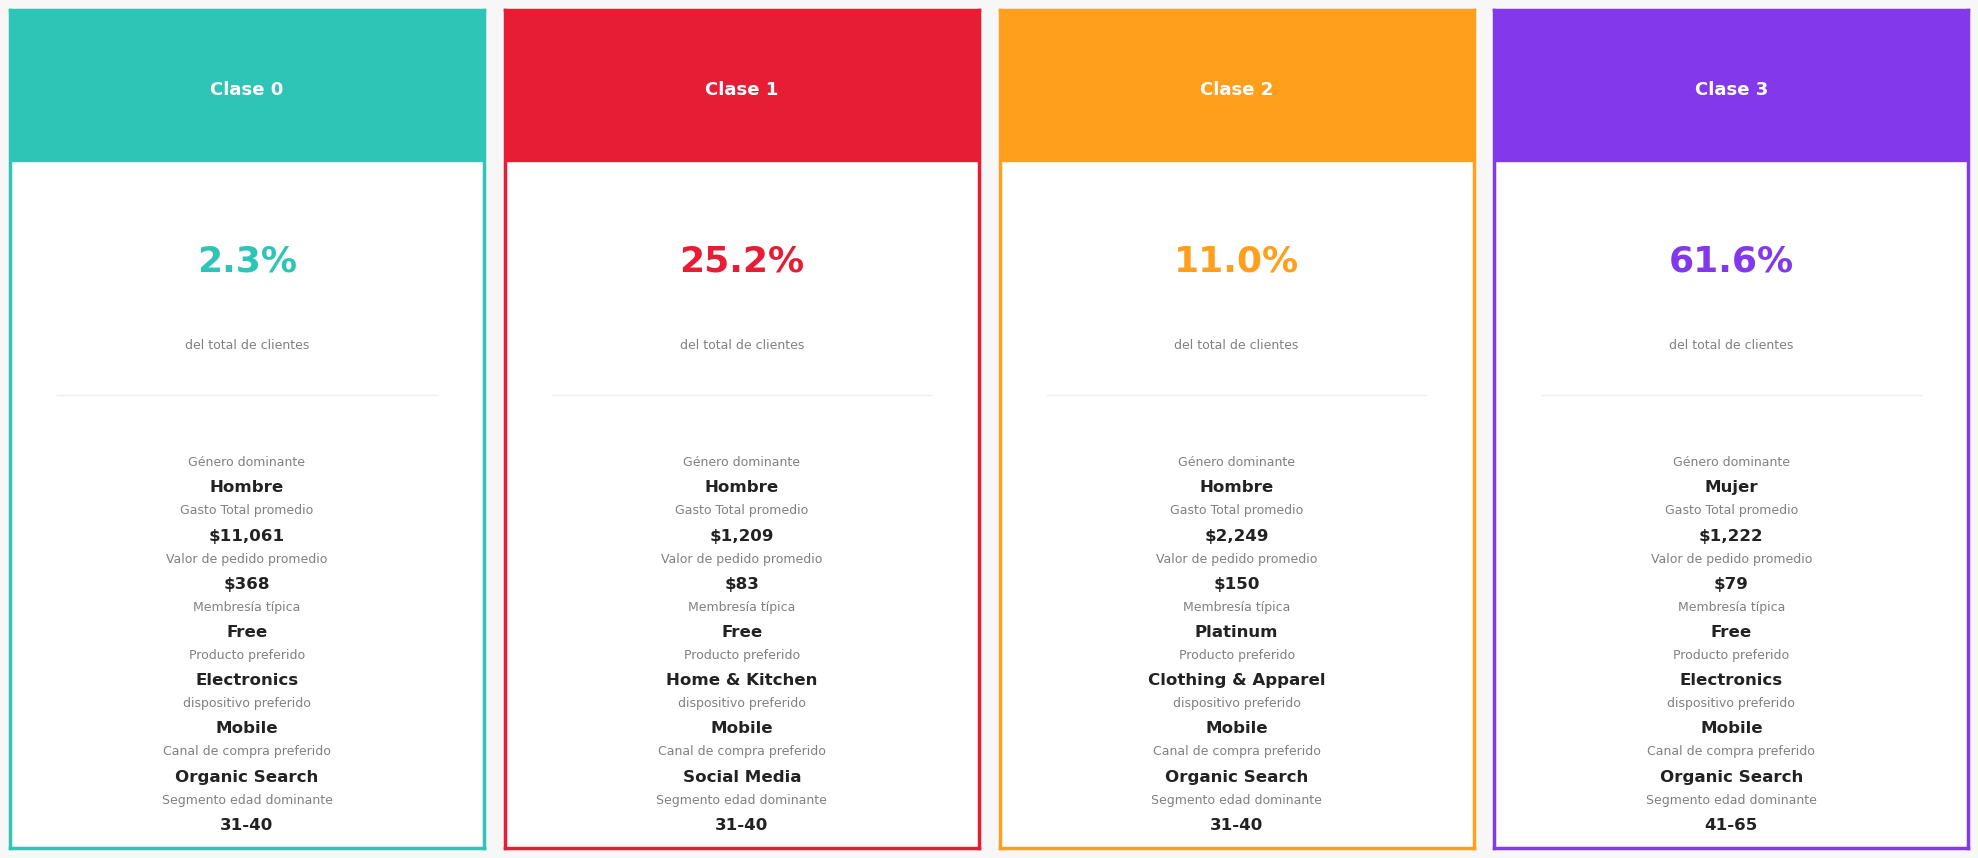

In [83]:


# ── Uso ───────────────────────────────────────────────────────────────────────
tarjetas_segmentos(
    df       = df_consumidores,
    col_pred = "mixed_pred",
    columnas = [
        {"col": "genero",                  "label": "Género dominante",  "tipo": "moda",
         "mapa": {0: "Mujer", 1: "Hombre"}},
        {"col": "gasto_total_usd",         "label": "Gasto Total promedio",    "tipo": "moneda"},
        {"col": "valor_promedio_pedido_usd","label": "Valor de pedido promedio",    "tipo": "moneda"},        
        {"col": "nivel_membresia",         "label": "Membresía típica",   "tipo": "moda"},
        {"col": "categoria_preferida",     "label": "Producto preferido",   "tipo": "moda"},
        {"col": "dispositivo_preferido",   "label": "dispositivo preferido",   "tipo": "moda"},
        {"col": 'canal_adquisicion',       "label": "Canal de compra preferido",   "tipo": "moda"},                 
        {"col": "edad", "label": "Segmento edad dominante", "tipo": "segmento",
        "bins": [0, 25, 30, 40, 65, float('inf')],
        "labels": ["18-25", "26-30", "31-40", "41-65", "65+"]},
    ],
    nombres_clase = ["Clase 0", "Clase 1", "Clase 2", "Clase 3","Clase 4"])

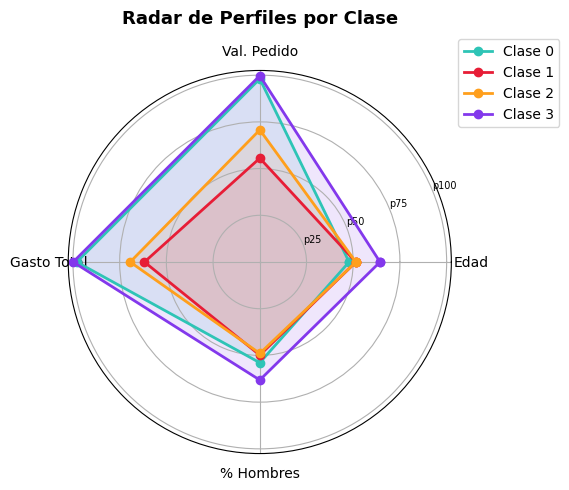

In [70]:
# ── Radar de perfiles ─────────────────────────────────────────────────────────
from scipy.stats import percentileofscore

VARS_CONT = ["edad", "valor_promedio_pedido_usd", "gasto_total_usd"]
VARS = VARS_CONT + ["genero"]

medias = df_consumidores.groupby("mixed_pred")[VARS].mean()

# Percentil de cada media respecto a la distribución real de individuos
perc = medias.copy()
for v in VARS_CONT:
    perc[v] = medias[v].apply(lambda m: percentileofscore(df_consumidores[v].dropna(), m) / 100)
# genero ya es 0-1 y se deja sin tocar

angles = np.linspace(0, 2*np.pi, len(VARS), endpoint=False).tolist(); angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for (clase, row), color in zip(perc.iterrows(), COLS):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", lw=2, color=color, label=f"Clase {clase}")
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Edad", "Val. Pedido", "Gasto Total", "% Hombres"])
ax.set_yticks([.25,.5,.75,1]); ax.set_yticklabels(["p25","p50","p75","p100"], fontsize=7)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.set_title("Radar de Perfiles por Clase", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout(); plt.show()

# modelo STP RFM

In [89]:
# Uso
evaluar_stepmix(
    df_consumidores,
    gaussian=['dias_desde_ultima_compra',"total_pedidos","valor_promedio_pedido_usd"]
)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  8.58it/s, max_LL=-2.47e+7, max_avg_LL=-3.19e+3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  7.65it/s, max_LL=-1.66e+7, max_avg_LL=-2.14e+3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.55it/s, max_LL=-1.26e+7, max_avg_LL=-1.62e+3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.36it/s, max_LL=-1.06e+7, max_avg_LL=-1.36e+3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.29it/s, max_LL=-8.54e+6, max_avg_LL=-1.1e+3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.44s/it, max_LL=-7.62e+6, max_avg_LL=-982]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.08it/s, max_LL=-6.86e+6, max_avg_LL=-883]


Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

In [87]:
#latent class using Stepmix

from stepmix.utils import get_mixed_descriptor

# Unspecified variables are simply not included in mixed_data
mixed_data, mixed_descriptor = get_mixed_descriptor(
    dataframe=df_consumidores,

    gaussian=['dias_desde_ultima_compra',"total_pedidos","valor_promedio_pedido_usd"],
)

# Pass descriptor to StepMix and fit model
model = StepMix(n_components=4, measurement=mixed_descriptor, verbose=1, random_state=2026)

# Fit model
model.fit(mixed_data)

Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.93it/s, max_LL=-1.26e+7, max_avg_LL=-1.62e+3]

MODEL REPORT
    Measurement model parameters
          model_name                      gaussian                              
          class_no                               0         1         2         3
          param variable                                                        
          means dias_desde_ultima_compra   35.9787   64.5057   41.9618  162.5996
                total_pedidos              16.7043   15.8074   16.3626   16.5500
                valor_promedio_pedido_usd  57.8410  375.0496  165.6164   75.3279


    Class weights
        Class 1 : 0.59
        Class 2 : 0.04
        Class 3 : 0.21
        Class 4 : 0.17
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 7761
    Number of latent classes      : 4
    Number of estimated parameters: 15
    Log-likelihood (LL)           : -12568386.3876
    -2LL                          : 25136772.7752
    Average LL                    : -1619.4287
    AIC           

,n_components,4
,n_steps,1
,measurement,"{'gaussian': {'model': 'gaussian', 'n_columns': 3}}"
,structural,'gaussian_unit'
,assignment,'modal'
,correction,None
,abs_tol,1e-10
,rel_tol,0.0
,max_iter,1000
,n_init,1
,save_param_init,False


## Graficos

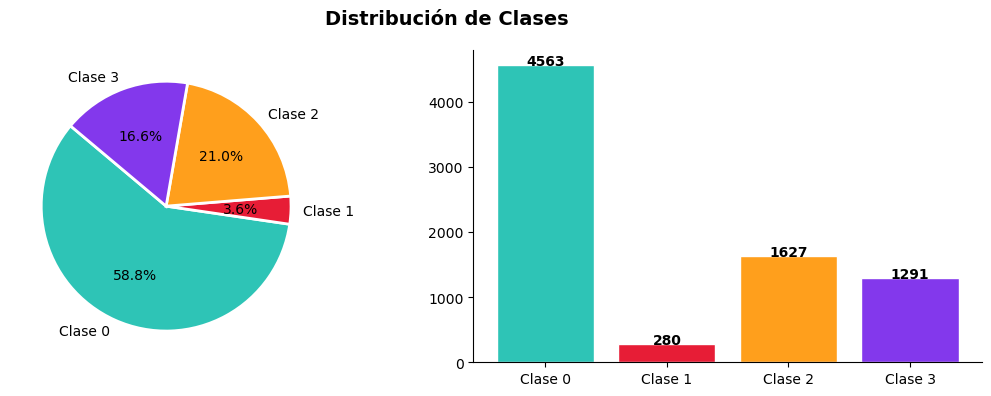

In [90]:
# ── Distribución de clases ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
df_consumidores['mixed_pred'] = model.predict(mixed_data)
conteo = df_consumidores['mixed_pred'].value_counts().sort_index()
clases = [f"Clase {i}" for i in conteo.index]
COLS = ["#2EC4B6","#E71D36","#FF9F1C","#8338EC","#3A86FF"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.pie(conteo, labels=clases, colors=COLS, autopct="%1.1f%%", startangle=140,
        wedgeprops=dict(linewidth=2, edgecolor="white"))
bars = ax2.bar(clases, conteo, color=COLS, edgecolor="white")
[ax2.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v),
          ha="center", fontweight="bold") for b, v in zip(bars, conteo)]
ax2.spines[["top","right"]].set_visible(False)
fig.suptitle("Distribución de Clases", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

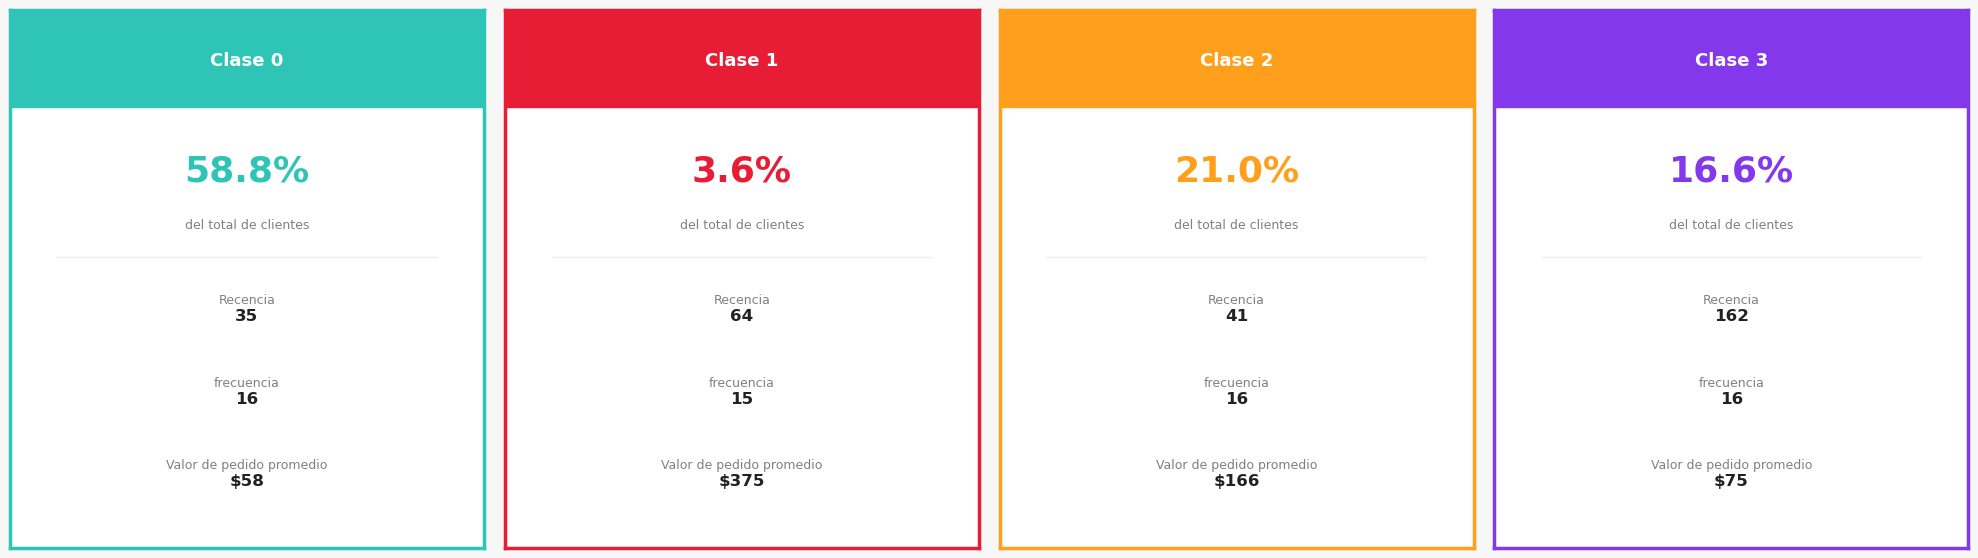

In [91]:


# ── Uso ───────────────────────────────────────────────────────────────────────
tarjetas_segmentos(
    df       = df_consumidores,
    col_pred = "mixed_pred",
    columnas = [
        {"col": "dias_desde_ultima_compra",         "label": "Recencia",    "tipo": "entero"},
        {"col": "total_pedidos",                    "label": "frecuencia",    "tipo": "entero"},
        {"col": "valor_promedio_pedido_usd","label": "Valor de pedido promedio",    "tipo": "moneda"},        

    ],
    nombres_clase = ["Clase 0", "Clase 1", "Clase 2", "Clase 3"])